In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [2]:
class Model(nn.Module):
    
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3): # How many Layers?

        # Input Layers (4 futures) ---> h1 N--> N---> output (3 class)
        
        super().__init__()
        self.fc1 = nn.Linear(in_features,h1)    # input layer
        self.fc2 = nn.Linear(h1, h2)            # hidden layer
        self.out = nn.Linear(h2, out_features)  # output layer
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [3]:
# Instantiate the Model class using parameter defaults:
torch.manual_seed(32)
model = Model()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [6]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


In [4]:
X = df.drop('target',axis=1)
y = df['target']

In [5]:
type(X)

pandas.core.frame.DataFrame

In [6]:
X = X.values
y = y.values

In [7]:
type(X)

numpy.ndarray

In [8]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train_test_split( )

In [12]:
train_test_split( )

ValueError: At least one array required as input

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=33)



In [ ]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [ ]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [60]:
criterion = nn.CrossEntropyLoss()  # multi class clasification problem 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # 0.000001

In [61]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [62]:
# epochabs
# an epoch is a one run through all the training data 

In [63]:
epochs = 100
losses = []

for i in range(epochs):
    
    i+=1

    # Forward and get a prediction 
    
    y_pred = model.forward(X_train)

    #Calculation Loss/error
    loss = criterion(y_pred, y_train)
    
    losses.append(loss.item())
    
    # a neat trick to save screen space:
    if i%10 == 1:
        print(f'epoch: {i}  loss: {loss.item()}')

    #Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch: 1  loss: 0.04151199385523796
epoch: 11  loss: 0.05907638370990753
epoch: 21  loss: 0.04960944131016731
epoch: 31  loss: 0.043130651116371155
epoch: 41  loss: 0.041683029383420944
epoch: 51  loss: 0.04150222986936569
epoch: 61  loss: 0.04148103669285774
epoch: 71  loss: 0.041455723345279694
epoch: 81  loss: 0.041411783546209335
epoch: 91  loss: 0.04139314219355583


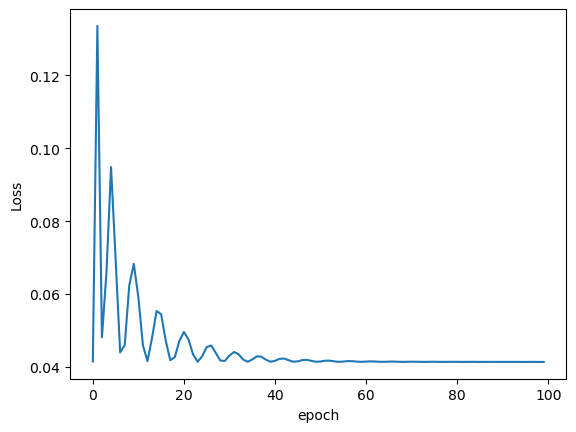

In [64]:
plt.plot(range(epochs), losses)

plt.ylabel('Loss')
plt.xlabel('epoch');

In [30]:
correct = 0

with torch.no_grad():

    for i,data in enumerate(X_test):

        y_val =model.forward(data)

        #1.) 2.) 3.)

        print(f'{i+1}.) {str(y_val)} {y_test[i]}')

        # 0 1 2

        if y_val.argmax().item() == y_test[i]:
            correct +=1

print(f'We got {correct} correct!')

1.) tensor([-2.8205,  6.4803, -1.0145]) 1
2.) tensor([-2.4630,  7.1412, -1.8081]) 1
3.) tensor([  7.9814,   1.1886, -12.2241]) 0
4.) tensor([-4.8562,  6.3026,  1.3067]) 1
5.) tensor([-9.3934,  4.2225,  7.4338]) 2
6.) tensor([-13.4211,   1.8034,  12.8416]) 2
7.) tensor([  7.8054,   1.4258, -12.1862]) 0
8.) tensor([  8.7649,   1.0591, -13.1944]) 0
9.) tensor([-9.3691,  4.2262,  7.3250]) 2
10.) tensor([-12.0320,   3.1541,  10.7873]) 2
11.) tensor([-12.5736,   2.8315,  11.5023]) 2
12.) tensor([  7.9732,   0.9370, -11.9811]) 0
13.) tensor([-11.9959,   2.5438,  11.0148]) 2
14.) tensor([-4.8925,  6.0516,  1.4775]) 1
15.) tensor([-9.9068,  3.9488,  8.0440]) 2
16.) tensor([-2.4449,  6.9555, -1.6940]) 1
17.) tensor([-7.3145,  4.6211,  4.8814]) 2
18.) tensor([  8.9339,   1.0852, -13.4533]) 0
19.) tensor([-4.5849,  6.2573,  0.9688]) 1
20.) tensor([-10.1447,   4.6992,   7.8929]) 2
21.) tensor([  8.4227,   1.0925, -12.7492]) 0
22.) tensor([  9.1965,   1.2723, -13.9907]) 0
23.) tensor([-12.3266,   2.

In [32]:
 print(f'{i+1}.) {str(y_val.argmax().item())} {y_test[i]}')

30.) 2 2


In [35]:
torch.save(model.state_dict(),'my_iris_model.pt')